In [1]:
import numpy as np
import matplotlib.pyplot as plt

from rfml.data import build_dataset
from rfml.nn.eval import (
    compute_accuracy,
    compute_accuracy_on_cross_sections,
    compute_confusion,
)
from rfml.nn.model import build_model
from rfml.nn.train import build_trainer, PrintingTrainingListener



In [5]:
train, val, test, le = build_dataset(
    dataset_name="RML2016.10a",
    path="RML2016.10a_dict.pkl/RML2016.10a_dict.pkl"
)
model = build_model(model_name="CNN", input_samples=128, n_classes=len(le))
trainer = build_trainer(
    strategy="standard", max_epochs=3, gpu=False
)  # Note: Disable the GPU here if you do not have one
trainer.register_listener(PrintingTrainingListener())
trainer(model=model, training=train, validation=val, le=le)
acc = compute_accuracy(model=model, data=test, le=le)
acc_vs_snr, snr = compute_accuracy_on_cross_sections(
    model=model, data=test, le=le, column="SNR"
)
cmn = compute_confusion(model=model, data=test, le=le)

# Calls to a plotting function could be inserted here
# For simplicity, this script only prints the contents as an example
print("===============================")
print("Overall Testing Accuracy: {:.4f}".format(acc))
print("SNR (dB)\tAccuracy (%)")
print("===============================")
for acc, snr in zip(acc_vs_snr, snr):
    print("{snr:d}\t{acc:0.1f}".format(snr=snr, acc=acc * 100))
print("===============================")
print("Confusion Matrix:")
print(cmn)

model.save("cnn.pt")

Epoch 0 completed!
		-Mean Training Loss: 1.361
		-Mean Validation Loss: 1.214
Epoch 1 completed!
		-Mean Training Loss: 1.182
		-Mean Validation Loss: 1.183
Epoch 2 completed!
		-Mean Training Loss: 1.123
		-Mean Validation Loss: 1.169
Training has Completed:

	Best Validation Loss: 1.169
	Best Epoch: 2
	Total Epochs: 2
Overall Testing Accuracy: 0.6073
SNR (dB)	Accuracy (%)
16	83.2
-14	20.0
0	80.1
2	81.5
-8	50.2
-20	12.9
8	83.3
-16	14.2
-6	64.5
-12	25.3
-10	37.2
14	84.1
18	83.7
10	82.5
12	83.2
-2	77.4
6	82.5
4	82.8
-18	13.1
-4	73.3
Confusion Matrix:
[[2.72500000e-01 4.74500000e-01 1.95000000e-01 3.33333333e-03
  3.66666667e-02 2.83333333e-03 5.66666667e-03 6.33333333e-03
  1.33333333e-03 5.00000000e-04 1.33333333e-03]
 [4.65000000e-02 7.37500000e-01 1.78166667e-01 2.00000000e-03
  1.70000000e-02 3.50000000e-03 5.33333333e-03 6.50000000e-03
  2.00000000e-03 8.33333333e-04 6.66666667e-04]
 [6.83333333e-03 2.93333333e-02 8.87166667e-01 6.83333333e-03
  2.13333333e-02 1.28333333e-02 9.666

In [6]:
# Cargar modelo ya entrenado
model = build_model(model_name="CNN", input_samples=128, n_classes=len(le))
model.load("cnn.pt")

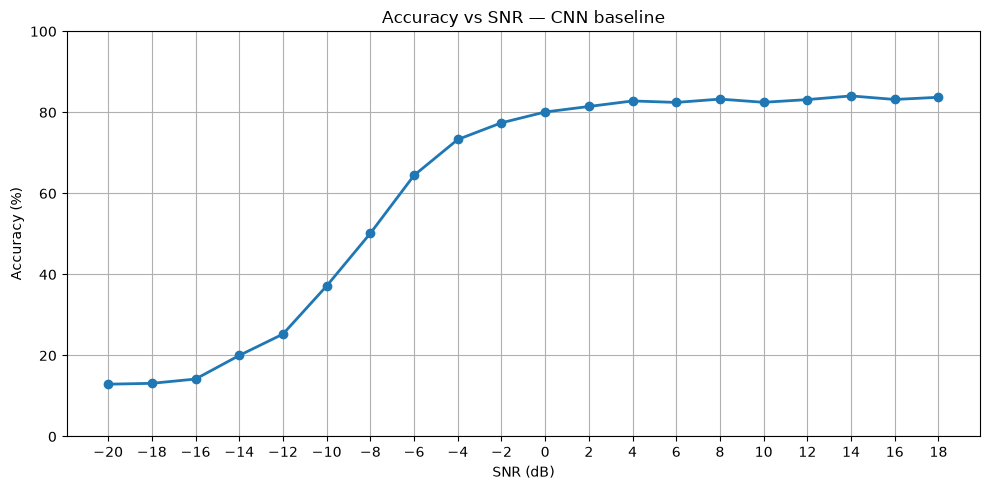

In [10]:
acc_vs_snr, snr = compute_accuracy_on_cross_sections(
    model=model, data=test, le=le, column="SNR"
)
acc_vs_snr_sorted = sorted(zip(snr, acc_vs_snr))
snr_sorted = [x[0] for x in acc_vs_snr_sorted]
acc_sorted = [x[1] * 100 for x in acc_vs_snr_sorted]

plt.figure(figsize=(10, 5))
plt.plot(snr_sorted, acc_sorted, marker="o", linewidth=2)
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs SNR — CNN baseline")
plt.grid(True)
plt.xticks(snr_sorted)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("accuracy_vs_snr.png", dpi=150)
plt.show()

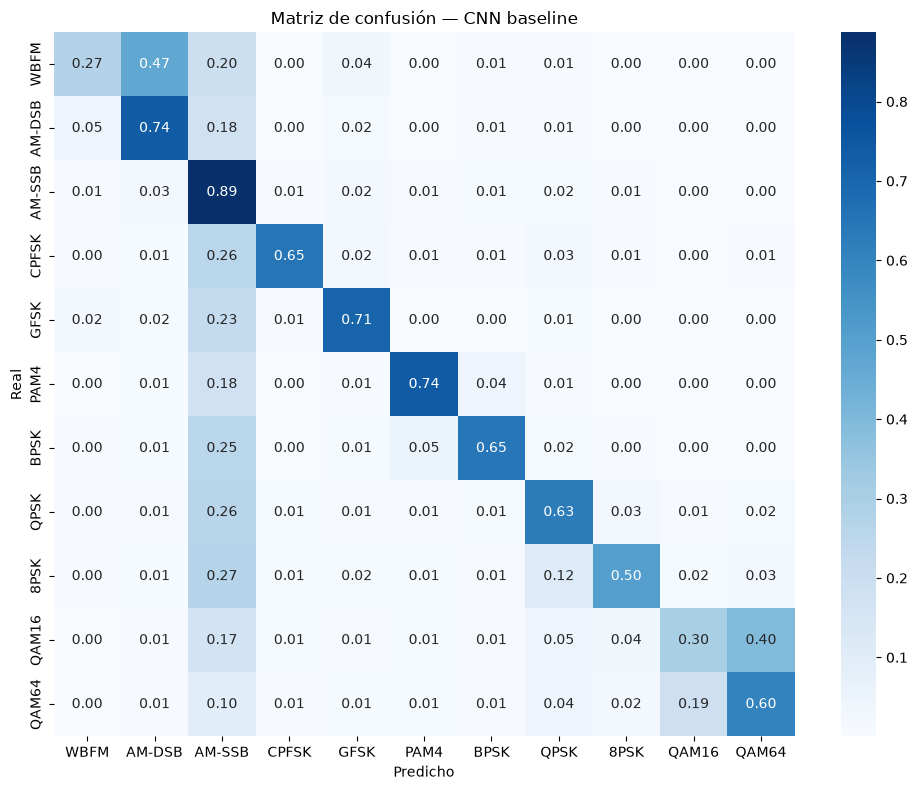

In [12]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cmn,
    annot=True,
    fmt=".2f",
    xticklabels=le.labels,
    yticklabels=le.labels,
    cmap="Blues",
    ax=ax
)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — CNN baseline")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()